<a href="https://colab.research.google.com/github/Plumz17/CVL_Assignment02/blob/main/CVL_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Second Computer Vision Assignment - Analysis of Object Detection Algorithm - Anders Emmanuel Tan (24/541351/PA/22964)
Description: In this Assignment I will be Implementing several Object Detection Algorithms to solve a certain problem, including:
1.   Thresholding: To find an optimal threshold (using Otsu's method) to seperate background and foreground objects
2.   Sliding Window: To find a specific subimage/template in an image.
3.   Background Modelling: To isolate foreground objects from the background, given a background model.

Additionally, I will be implementing manually two evaluation metrics which are IoU and Accuracy

## 0. Setting Up Image to be Processed
Description: For this first section, we will be preparing the images that will later be processed. Since the uploaded files in Google Colab are only available in the runtime, I will be attaining those files by cloning them from the Github Submission link. Additionaly, we will also be importing the libaries that we will be using for this submission to import and process the images. We will also convert the images into grayscale in order to ease the object detection process.

In [11]:
# Cloning Github Repository to get the Image files
!rm -rf CVL_Assignment02
!git clone https://github.com/Plumz17/CVL_Assignment02

Cloning into 'CVL_Assignment02'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 16 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 1.88 MiB | 10.72 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [12]:
# Import Important Libraries
import cv2 # For Reading Image
import numpy as np # For Manipulating Numeric types
import matplotlib.pyplot as plt # For Showing Image
import math # For Math

filename_waldo = "/content/CVL_Assignment02/waldo.jpg"
filename_template = "/content/CVL_Assignment02/template.jpg"

img_sliding = cv2.imread(filename_waldo) # Read Image
img_sliding = cv2.cvtColor(img_sliding, cv2.COLOR_BGR2GRAY) # Change the color map
img_sliding_template = cv2.imread(filename_template) # Read Image
img_sliding_template = cv2.cvtColor(img_sliding_template, cv2.COLOR_BGR2GRAY) # Change the color map

## 1. Sliding Window
Description: For this first section, we will be creating a simple implementation of the Sliding Window Algorithm using Template Matching. Since this method is computationally expensive, we will only be using template matching to detect one object. In my implementation, we will match the template with each window of the same size with the stride of 3 and then we will keep track of the SSD value of each comparison in a matrix. After the matrix is fully formed, we will locate the window with the highest SSD value to the template, since this implementation is simple and only meant to detect one object. We will then draw a bounding box in the aforementioned window and we will compare it to the ground truth (which has been manually selected) using IoU and accuracy metrics.

### 1A. Template Matching

In [30]:
def template_match(image, template, stride = 3):
  #Get height and width from image and template
  H, W = image.shape
  h, w = template.shape
  #Get the range of the y and x based on the given stride, in this case 3.
  ys = range(0, H - h + 1, stride)
  xs = range(0, W - w + 1, stride)
  #Construct an empty SSD matrix with the total size being the amount of time the template is compared to each frame
  ssd_matrix = np.zeros((len(ys), len(xs)))

  #calculate ssd value for each window comparison
  for i, y in enumerate(ys):
    for j, x in enumerate(xs):
      window = image[y:y+h, x:x+w]
      ssd_matrix[i, j] = np.sum((window - template) ** 2)
  return ssd_matrix, ys, xs

template_match(img_sliding, img_sliding_template)

(array([[553435., 556224., 550022., ..., 554009., 553045., 554434.],
        [556131., 551734., 556604., ..., 548144., 547221., 558285.],
        [552268., 558231., 556548., ..., 550789., 553431., 555844.],
        ...,
        [572977., 575165., 581330., ..., 565853., 560601., 566617.],
        [585504., 568632., 573635., ..., 548340., 564138., 567453.],
        [581762., 578260., 579605., ..., 561473., 566624., 582013.]]),
 range(0, 1546, 3),
 range(0, 2505, 3))

### 1B. Finding the Best Match (Highest SSD Window)

In [27]:
def find_best_match(ssd_matrix, ys, xs):
  best_score = np.inf
  best_y, best_x = 0, 0

  #Loop over every value in the ssd matrix to find the coordinates of the max score
  for i in range(ssd_matrix.shape[0]):
    for j in range(ssd_matrix.shape[1]):
      if ssd_matrix[i, j] < best_score:
        best_score = ssd_matrix[i, j]
        best_y, best_x = ys[i], xs[j]

  return best_y, best_x, best_score

best_y, best_x, best_score = find_best_match(*template_match(img_sliding, img_sliding_template))
print(best_y, best_x, best_score)

592 1560 0.0


### 1C. Results and Evaluation Metrices

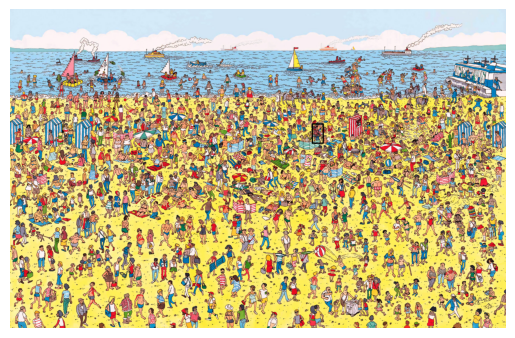

In [28]:
#This block of code displays the bounding box of the window with the highest ssd score.
img_waldo_box = cv2.rectangle(cv2.imread(filename_waldo), (best_x, best_y), (best_x + img_sliding_template.shape[1], best_y + img_sliding_template.shape[0]), (0, 0, 0), 5)
plt.imshow(cv2.cvtColor(img_waldo_box, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [35]:
def calculate_iou(pred_x, pred_y, gt_x, gt_y, template_w, template_h):
  #Get Predicted Bounding Box Coordinates
  pred_x1, pred_y1 = pred_x, pred_y
  pred_x2, pred_y2 = pred_x + template_w, pred_y + template_h

  #Get Ground Truth Bounding Box Coordinates
  gt_x1, gt_y1 = gt_x, gt_y
  gt_x2, gt_y2 = gt_x + template_w, gt_y + template_h

  #Calculate intersection rectangle coordinates
  inter_x1 = max(pred_x1, gt_x1)
  inter_y1 = max(pred_y1, gt_y1)
  inter_x2 = min(pred_x2, gt_x2)
  inter_y2 = min(pred_y2, gt_y2)

  # Calculate intersection area (0 if no overlap)
  inter_w = max(0, inter_x2 - inter_x1)
  inter_h = max(0, inter_y2 - inter_y1)
  intersection_area = inter_w * inter_h

  # Calculate union area
  pred_area = template_w * template_h
  gt_area   = template_w * template_h
  union_area = pred_area + gt_area - intersection_area

  if union_area > 0.0:
    iou = intersection_area/union_area
  else:
    iou = 0

  return iou

def calculate_accuracy(pred_x, pred_y, gt_x, gt_y, template_w, template_h, total_predictions, iou_threshold=0.5):
    iou = calculate_iou(pred_x, pred_y, gt_x, gt_y, template_w, template_h)
    is_correct = iou >= iou_threshold  # 1 if match, 0 if not
    accuracy = is_correct / total_predictions
    return accuracy

# Manually Extracted ground truth
gt_x, gt_y = 1564, 594
template_h, template_w = img_sliding_template.shape

iou = calculate_iou(best_x, best_y, gt_x, gt_y, template_w, template_h)
accuracy = calculate_accuracy(best_x, best_y, gt_x, gt_y, template_w, template_h, 1)

print(f"Predicted: ({best_x}, {best_y})")
print(f"Ground Truth: ({gt_x}, {gt_y})")
print(f"IoU: {iou:.4f}")
print(f"Accuracy (IoU >= 0.5): {accuracy}")

Predicted: (1560, 592)
Ground Truth: (1564, 594)
IoU: 0.8345
Accuracy (IoU >= 0.5): 1.0


### 1D. Analysis
Analysis: From the final IoU and Accuracy of my Template Matching Algorithm, we can see that it has sufficiently detected the window/subimage from the image since the predicted coordinate (1560, 592) is very close to the manually extracted ground truth (1564, 594), with a pixel offset of only 4 pixels on the x axis and 2 pixels in the y axis. This slight discrepancy is probably caused by the stride of 3 being used to lower the computational time. Additionallyy, an IoU of ~83% indicates a strong overlap between the predicted and ground truth bounding boxes. However, the accuracy metric here might not be fully representative since we only have a single object (since 1 correct prediction out of 1 doesn't really tell us much about the effectivity of the algorithm if applied on images with multiple objects in the same class).

##